# 03 — Эксперименты: CV, подбор гиперпараметров, сабмит

Пайплайн целиком в ноутбуке: препроцессинг из `src`, модели, сабмит.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.config import N_CV_SPLITS, RANDOM_STATE, project_root
from src.modeling import (
    cv_lgbm_mean_logloss,
    lgbm_from_search,
    random_search_lgbm,
    train_val_holdout,
    write_submission,
)
from src.preprocessing import prepare_from_paths

FAST = True
N_ITER = 6 if FAST else 12
CV_FOLDS = 3 if FAST else 5

In [2]:
base = project_root()
raw = base / "data" / "raw"
proc = base / "data" / "processed"
proc.mkdir(parents=True, exist_ok=True)
fig_dir = base / "report" / "images"
fig_dir.mkdir(parents=True, exist_ok=True)

X, y, X_kg, kid = prepare_from_paths(raw / "train.csv", raw / "test.csv")
print(X.shape, y.shape, X_kg.shape)

(114321, 137) (114321,) (114393, 137)


In [3]:
base_params = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 50,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
}
m, s = cv_lgbm_mean_logloss(X, y, base_params, n_splits=N_CV_SPLITS, random_state=RANDOM_STATE)
print("baseline_cv_logloss", round(m, 5), "+/-", round(s, 5))

baseline_cv_logloss 0.46393 +/- 0.00181


In [4]:
search = random_search_lgbm(X, y, n_iter=N_ITER, cv=CV_FOLDS, random_state=RANDOM_STATE)
rows = []
for i in range(min(15, len(search.cv_results_["params"]))):
    rows.append(
        {
            "rank": int(search.cv_results_["rank_test_score"][i]),
            "mean_score": float(search.cv_results_["mean_test_score"][i]),
            "params": search.cv_results_["params"][i],
        }
    )
display(pd.DataFrame(rows).sort_values("mean_score", ascending=False).head(10))
print("best_params", search.best_params_)

/Users/kaosintsev/Desktop/ml_project/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/kaosintsev/Desktop/ml_project/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/kaosintsev/Desktop/ml_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/kaosintsev/Desktop/ml_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                     

,rank,mean_score,params
0,1,NaN,"{'subsample': 0.7, 'reg_lambda': 1.0, 'num_lea..."
1,1,NaN,"{'subsample': 0.7, 'reg_lambda': 0.1, 'num_lea..."
2,1,NaN,"{'subsample': 1.0, 'reg_lambda': 1.0, 'num_lea..."
3,1,NaN,"{'subsample': 0.85, 'reg_lambda': 5.0, 'num_le..."
4,1,NaN,"{'subsample': 1.0, 'reg_lambda': 0.0, 'num_lea..."
5,1,NaN,"{'subsample': 0.7, 'reg_lambda': 0.1, 'num_lea..."


best_params {'subsample': 0.7, 'reg_lambda': 1.0, 'num_leaves': 31, 'n_estimators': 400, 'min_child_samples': 100, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [5]:
X_tr, X_va, _, y_tr, y_va, _ = train_val_holdout(
    X, y, val_size=0.15, test_size=0.15, random_state=RANDOM_STATE
)
model = lgbm_from_search(search, random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)
p = model.predict_proba(X_va)[:, 1]
print("holdout_logloss", round(log_loss(y_va, p), 6))
print("holdout_roc_auc", round(roc_auc_score(y_va, p), 6))

holdout_logloss 0.472368
holdout_roc_auc 0.747456


In [6]:
model.fit(X, y)
proba = model.predict_proba(X_kg)[:, 1]
sub_path = proc / "submission_notebook.csv"
write_submission(kid, proba, sub_path)
print("saved", sub_path)

saved /Users/kaosintsev/Desktop/ml_project/data/processed/submission_notebook.csv


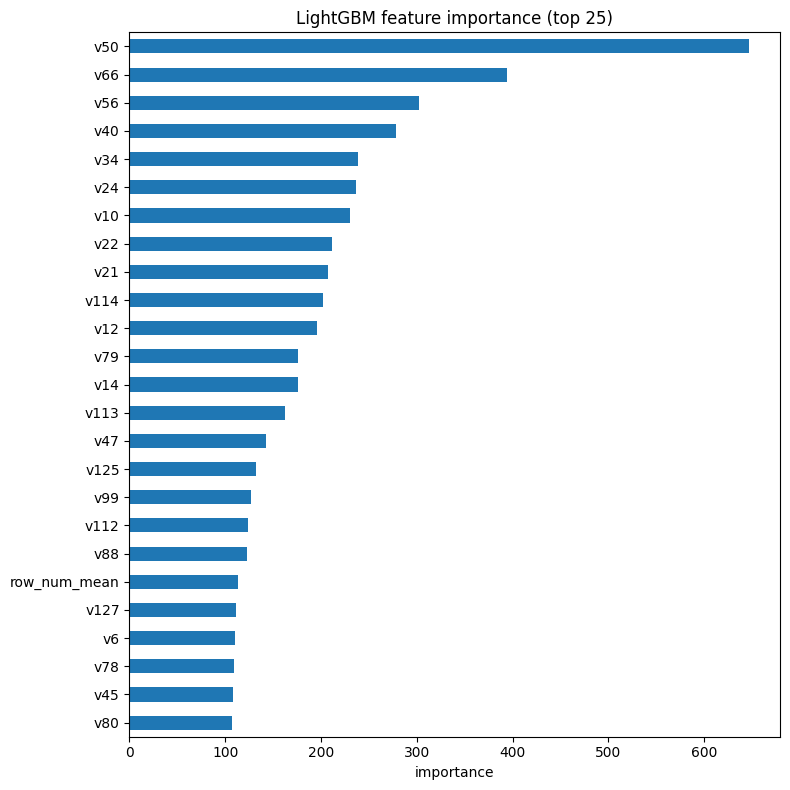

In [7]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(25)
plt.figure(figsize=(8, 8))
imp.sort_values().plot(kind="barh")
plt.title("LightGBM feature importance (top 25)")
plt.xlabel("importance")
plt.tight_layout()
plt.savefig(fig_dir / "lgbm_feature_importance.png", dpi=120)
plt.show()